In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!ls /content/drive/MyDrive/fire_data
!ls /content/drive/MyDrive/fire_data/train
!ls /content/drive/MyDrive/fire_data/valid


data.yaml  README.dataset.txt  README.roboflow.txt  train  valid
images	labels
images	labels


In [ ]:
!git clone https://github.com/ultralytics/yolov5.git
%cd yolov5


Cloning into 'yolov5'...
remote: Enumerating objects: 17777, done.
remote: Counting objects: 100% (161/161), done.
remote: Compressing objects: 100% (107/107), done.
remote: Total 17777 (delta 98), reused 54 (delta 54), pack-reused 17616 (from 2)
Receiving objects: 100% (17777/17777), 17.14 MiB | 16.57 MiB/s, done.
Resolving deltas: 100% (12076/12076), done.
/content/yolov5


In [ ]:
!pip install -r requirements.txt


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 69.4 MB/s eta 0:00:00


In [ ]:
import yaml

DATASET_PATH = "/content/drive/MyDrive/fire_data"
DATA_YAML_PATH = f"{DATASET_PATH}/data.yaml"

with open(DATA_YAML_PATH, 'r') as f:
    data = yaml.safe_load(f)

data['train'] = f"{DATASET_PATH}/train/images"
data['val']   = f"{DATASET_PATH}/valid/images"

with open(DATA_YAML_PATH, 'w') as f:
    yaml.dump(data, f)

print("Updated data.yaml:")
print(data)



Updated data.yaml:
{'train': '/content/drive/MyDrive/fire_data/train/images', 'val': '/content/drive/MyDrive/fire_data/valid/images', 'test': '../test/images', 'nc': 1, 'names': ['fire'], 'roboflow': {'workspace': 'aj-garcia-736tc', 'project': 'fire-dataset-for-yolov8', 'version': 10, 'license': 'CC BY 4.0', 'url': 'https://universe.roboflow.com/aj-garcia-736tc/fire-dataset-for-yolov8/dataset/10'}}


In [ ]:
!python train.py \
  --img 320 \
  --batch 16 \
  --epochs 80 \
  --data /content/drive/MyDrive/fire_data/data.yaml \
  --weights yolov5n.pt \
  --cache \
  --device 0


Streaming output truncated to the last 5000 lines.
      67/79     0.648G    0.03229   0.009788          0         49        320:  68% 137/200 [00:17<00:07,  8.49it/s]/content/yolov5/train.py:414: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(amp):
      67/79     0.648G    0.03226   0.009775          0         37        320:  69% 138/200 [00:17<00:07,  8.06it/s]/content/yolov5/train.py:414: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(amp):
      67/79     0.648G    0.03228   0.009765          0         29        320:  70% 139/200 [00:17<00:07,  8.05it/s]/content/yolov5/train.py:414: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(amp):
      67/79     0.648G    0.032

In [ ]:
!ls runs/train/exp/weights


best.onnx  best.onnx.data  best.pt  last.pt


In [ ]:
!cp -r runs/train/exp/weights /content/drive/MyDrive/fire_models/


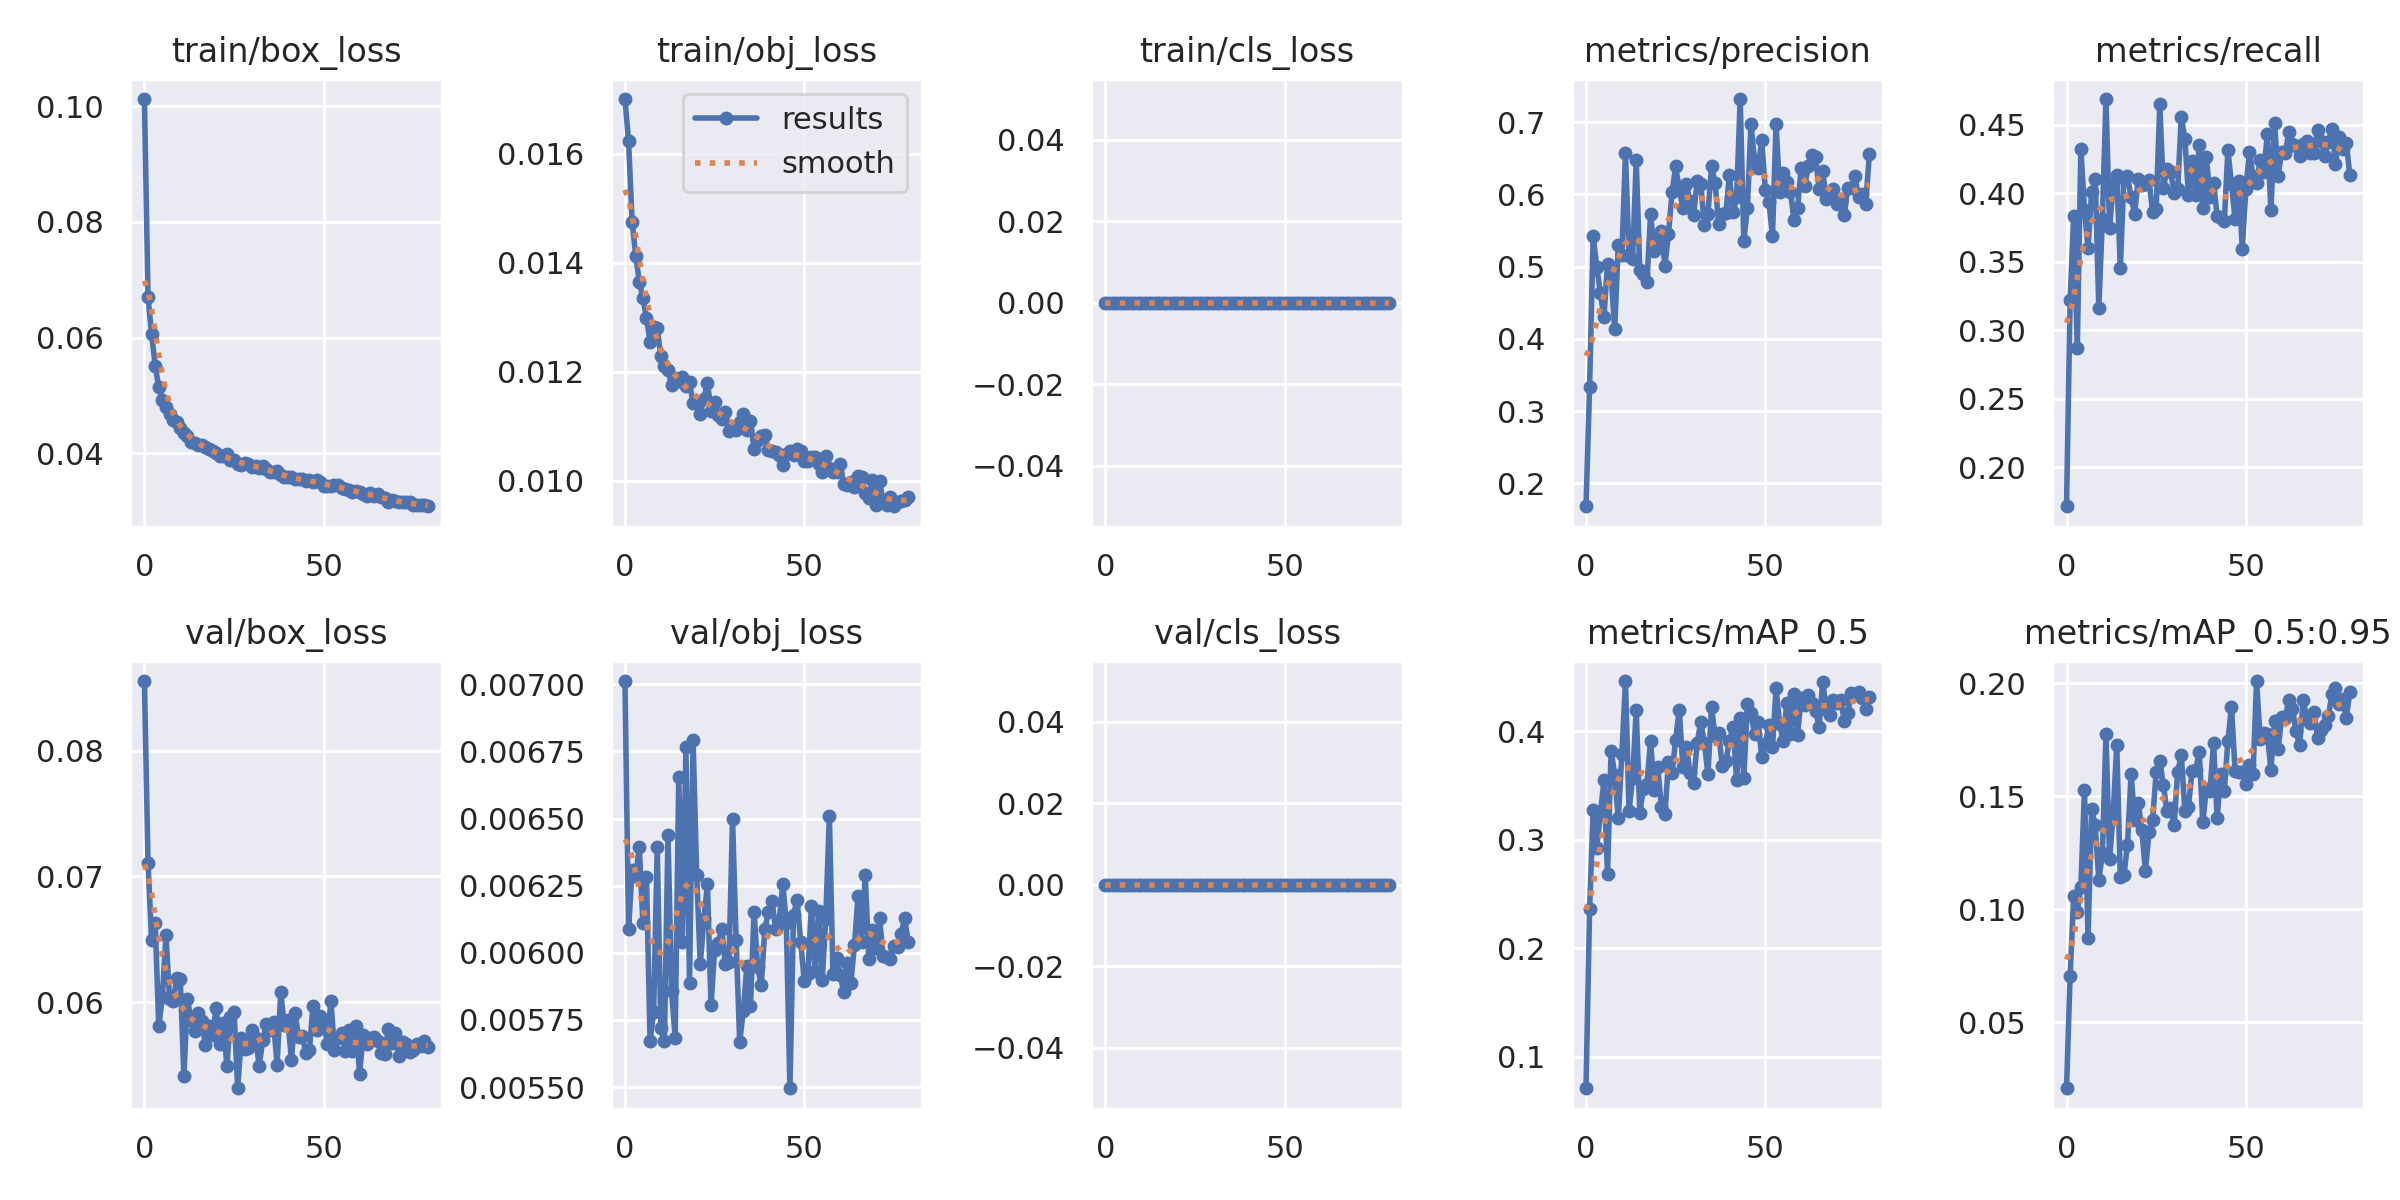

In [ ]:
from IPython.display import Image
Image("runs/train/exp/results.png")


In [ ]:
!ls runs/train


exp


In [ ]:
!python export.py \
  --weights runs/train/exp/weights/best.pt \
  --img 320 \
  --batch 1 \
  --include onnx


export: data=data/coco128.yaml, weights=['runs/train/exp/weights/best.pt'], imgsz=[320], batch_size=1, device=cpu, half=False, inplace=False, keras=False, optimize=False, int8=False, per_tensor=False, dynamic=False, cache=, simplify=False, mlmodel=False, opset=17, verbose=False, workspace=4, nms=False, agnostic_nms=False, topk_per_class=100, topk_all=100, iou_thres=0.45, conf_thres=0.25, include=['onnx']
YOLOv5 🚀 v7.0-453-geed9bc19 Python-3.12.12 torch-2.9.0+cu126 CPU

Fusing layers... 
Model summary: 157 layers, 1760518 parameters, 0 gradients, 4.1 GFLOPs

PyTorch: starting from runs/train/exp/weights/best.pt with output shape (1, 6300, 6) (3.6 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0', 'onnxscript'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 8 packages in 144ms
Prepared 3 packages in 1.24s
Installed 3 packages in 270ms
 + onnx==1.20.0
 + onnx-ir==0.1.13
 + onnxscript==0.5.7

requirements: AutoUpdate success ✅ 2.3s
WARNING ⚠

In [ ]:
!pip install tensorflow tf2onnx


INFO: pip is looking at multiple versions of onnx to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.8/455.8 kB 32.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 105.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 14.5 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.5
    Uninstalling protobuf-5.29.5:
      Successfully uninstalled protobuf-5.29.5
  Attempting uninstall: onnx
    Found existing installation: onnx 1.20.0
    Uninstalling onnx-1.20.0:
      Successfully uninstalled onnx-1.20.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydf 0.13.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 3.20.3 which is incompatible.
opentelemetry-proto 1.37.0 requires

In [ ]:
!python -m tf2onnx.convert \
  --onnx best.onnx \
  --output fire_yolov5n.tflite


2025-12-25 07:21:22.293940: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766647282.327209   35753 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766647282.335597   35753 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1766647282.352208   35753 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766647282.352239   35753 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766647282.352244   35753 computation_placer.cc:177] computation placer alr

In [ ]:
!cp best.onnx /content/drive/MyDrive/
!cp fire_yolov5n.tflite /content/drive/MyDrive/


cp: cannot stat 'best.onnx': No such file or directory
cp: cannot stat 'fire_yolov5n.tflite': No such file or directory


In [ ]:
!python detect.py \
  --weights runs/train/exp/weights/best.pt \
  --img 640 \
  --conf 0.25 \
  --source /content/Fire.jpg


detect: weights=['runs/train/exp/weights/best.pt'], source=/content/Fire.jpg, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-453-geed9bc19 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)

Fusing layers... 
Model summary: 157 layers, 1760518 parameters, 0 gradients, 4.1 GFLOPs
image 1/1 /content/Fire.jpg: 448x640 2 fires, 34.0ms
Speed: 0.6ms pre-process, 34.0ms inference, 67.1ms NMS per image at shape (1, 3, 640, 640)
Results saved to runs/detect/exp2


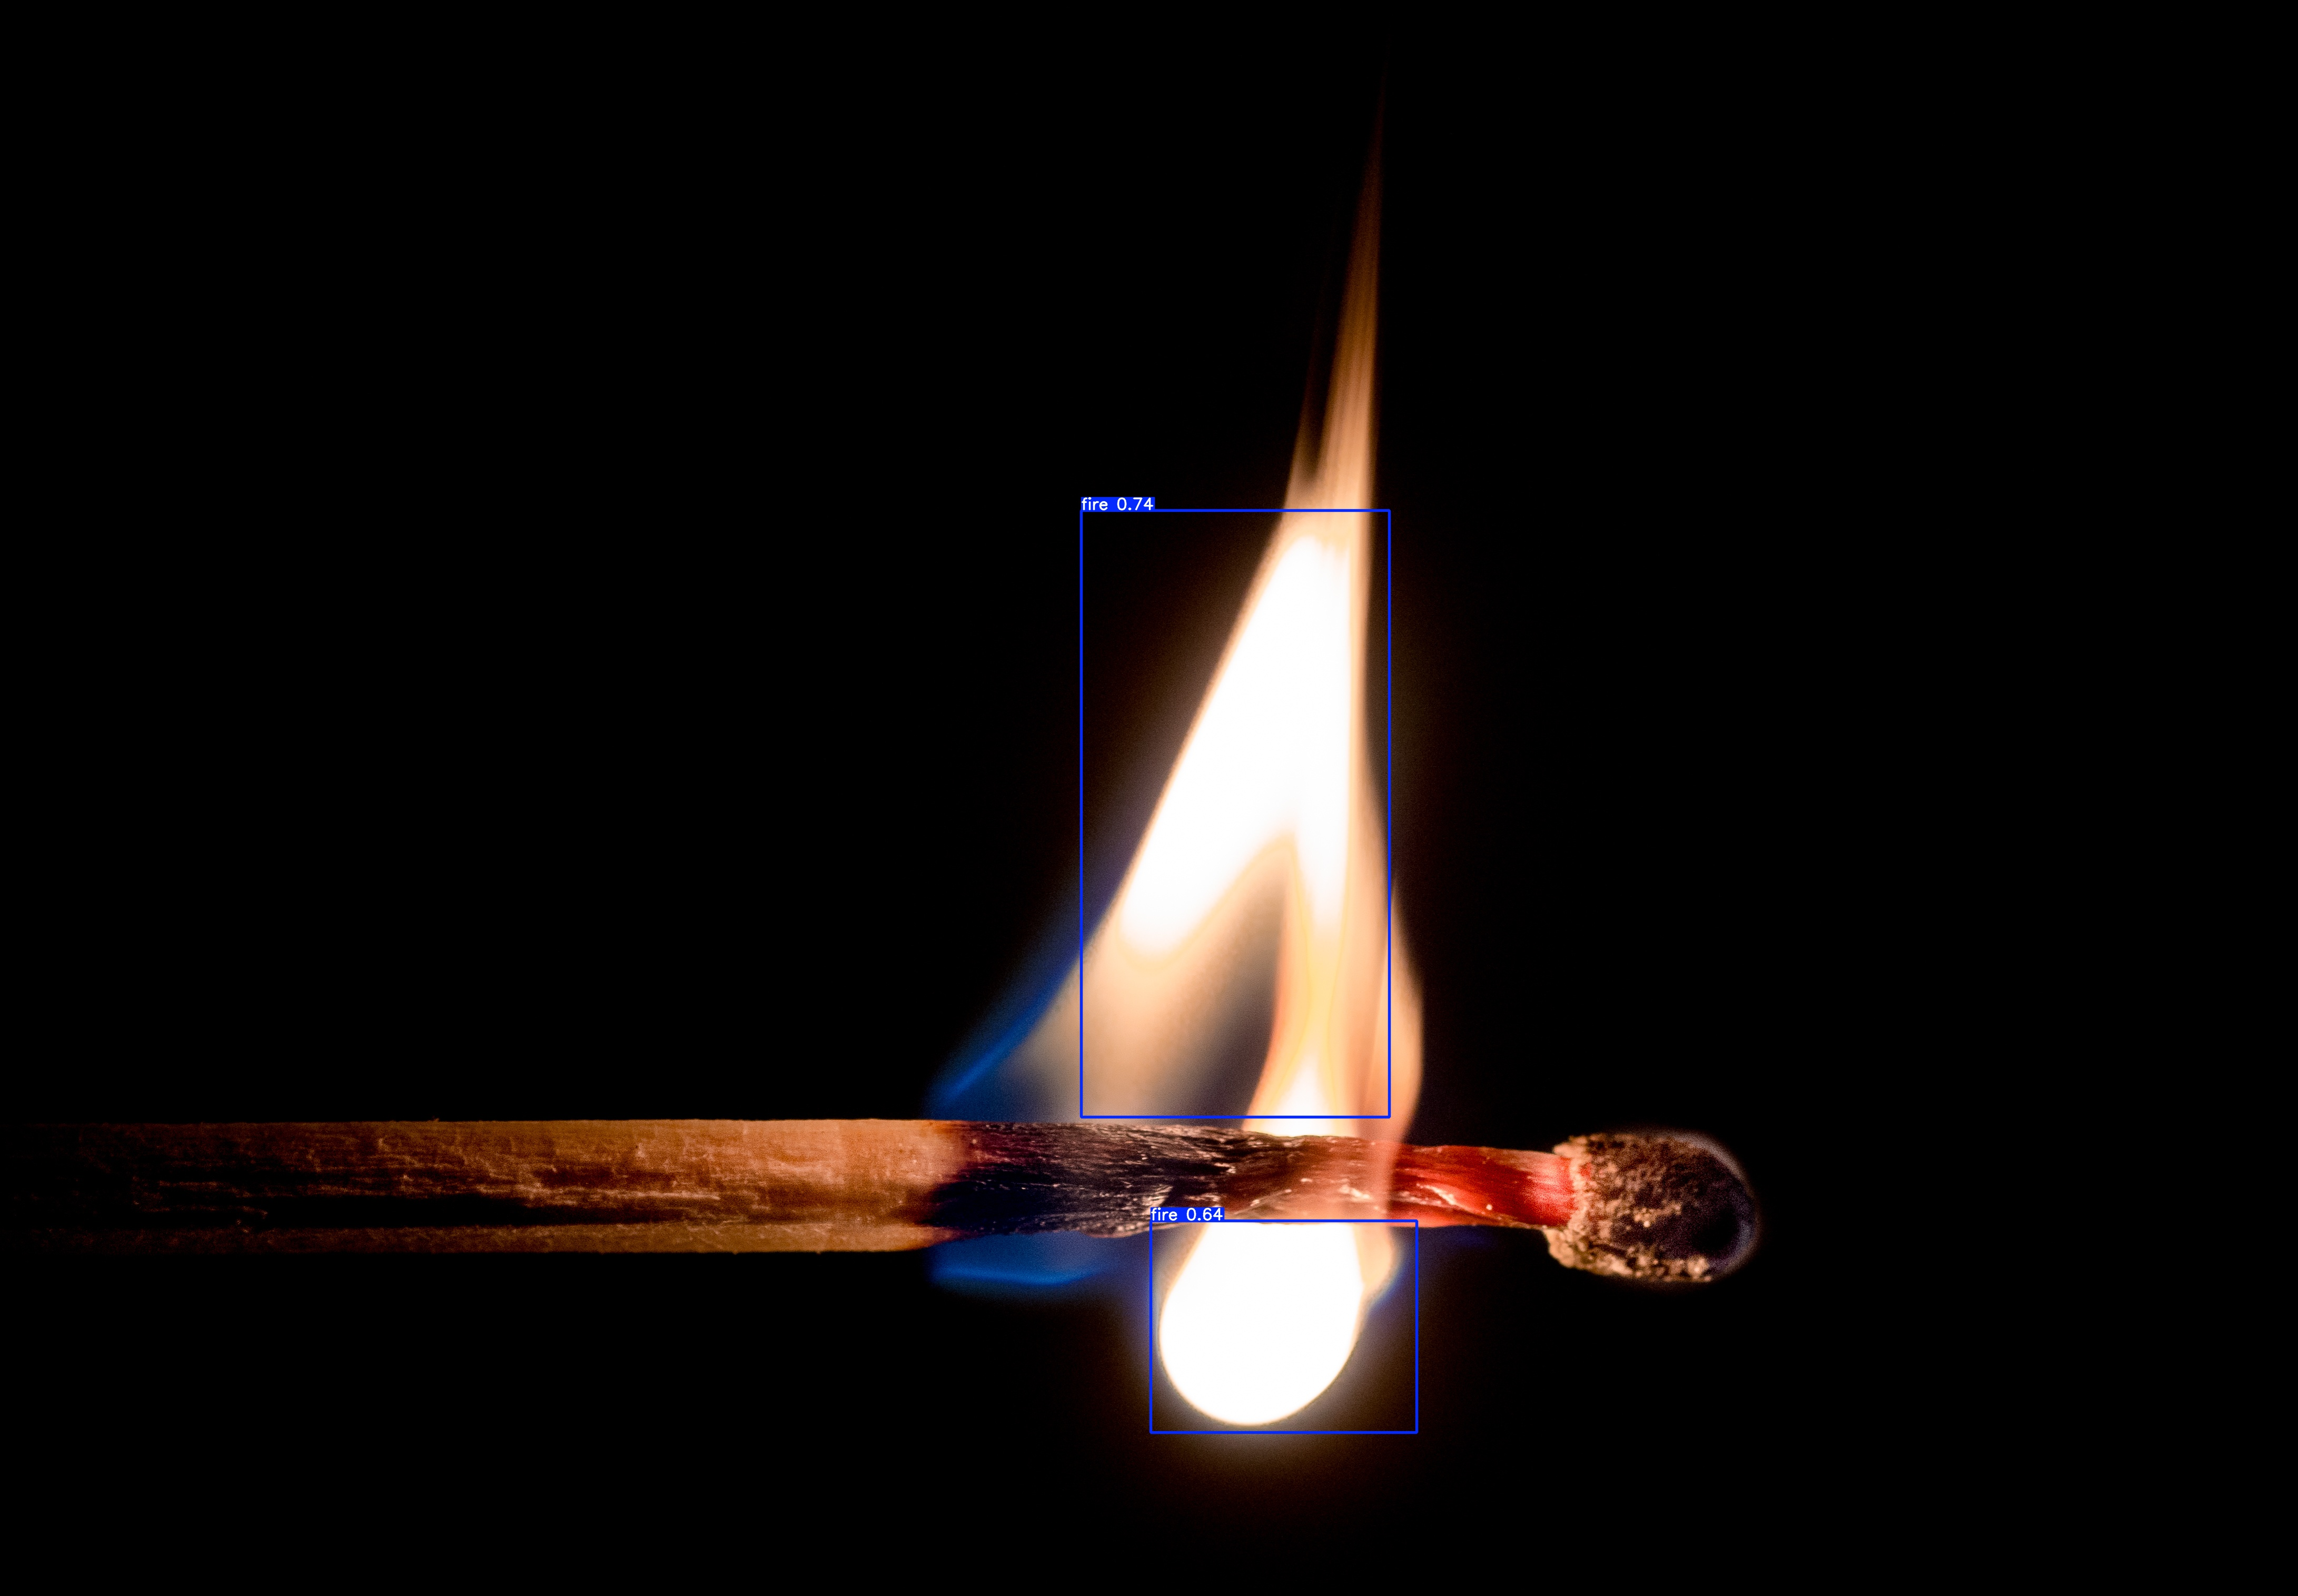

In [ ]:
from IPython.display import Image
Image("runs/detect/exp2/Fire.jpg")


In [ ]:
!python detect.py \
  --weights runs/train/exp/weights/best.onnx \
  --img 320 \
  --conf 0.5 \
  --source /content/fire\ \(1\).jpg


detect: weights=['runs/train/exp/weights/best.onnx'], source=/content/fire (1).jpg, data=data/coco128.yaml, imgsz=[320, 320], conf_thres=0.5, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-453-geed9bc19 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)

Loading runs/train/exp/weights/best.onnx for ONNX Runtime inference...
image 1/1 /content/fire (1).jpg: 320x320 1 fire, 5.3ms
Speed: 20.5ms pre-process, 5.3ms inference, 164.8ms NMS per image at shape (1, 3, 320, 320)
Results saved to runs/detect/exp6


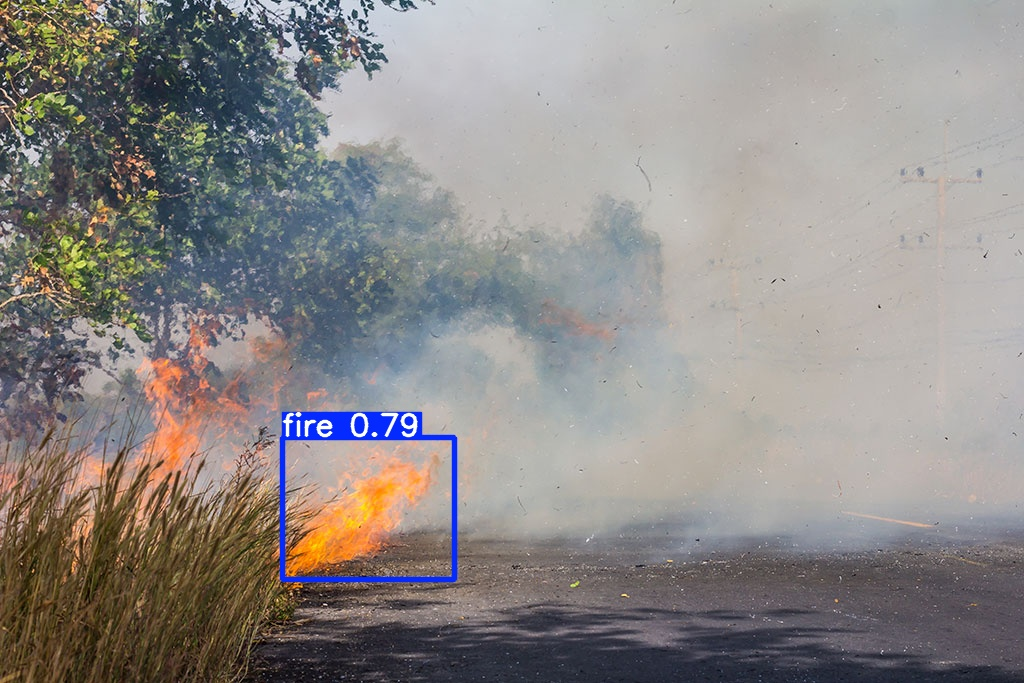

In [ ]:
from IPython.display import Image
Image("runs/detect/exp6/fire (1).jpg")
